In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
import wooldridge as woo
import pandas as pd
import wooldridge as woo

In [2]:
reg = LinearRegression(fit_intercept=False)
data = woo.dataWoo('injury')

In [3]:
def plot_histograms(data_list, titles, bins=30, figsize=(12, 5), 
                   xlabel='X label', 
                   ylabel='Y label',
                   overall_title='Histogram Title',
                   colors=None, sharey=True):
    
    n_plots = len(data_list)
    
    # Create subplots
    fig, axes = plt.subplots(1, n_plots, figsize=figsize, sharey=sharey)
    
    # Handle case of single plot (axes won't be an array)
    if n_plots == 1:
        axes = [axes]
    
    # Default colors if not provided
    if colors is None:
        colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown', 'pink', 'gray']
    
    # Plot each histogram
    for i, (data, title, ax) in enumerate(zip(data_list, titles, axes)):
        color = colors[i % len(colors)]  # Cycle through colors if more plots than colors
        ax.hist(data, bins=bins, edgecolor='black', alpha=0.7, color=color)
        ax.set_xlabel(xlabel)
        ax.set_title(title)
        
        # Only set ylabel on first subplot
        if i == 0:
            ax.set_ylabel(ylabel)
    
    # Add overall title
    fig.suptitle(overall_title, fontsize=14, y=1.02)
    
    plt.tight_layout()
    plt.show()

### PART A

Simple linear regression to approach this model ---- duration_i = β₀ + β₁(HighEarner_i) + ε_i
By a causal model β₁ would indicate the effect of being a high earner on unemployment duration.

This model, however, is misleading as it fails to provide causal identification due to <b>selection bias</b>, as high and lower earners face different occupational hazards, <b>omitted variable bias</b>, as many more endogenous variables are not considered such as labor market economic conditions, and <b>reverse causality</b>, as a desier for higher unemployment durations could cause individuals to seek higher wages.

### PART B

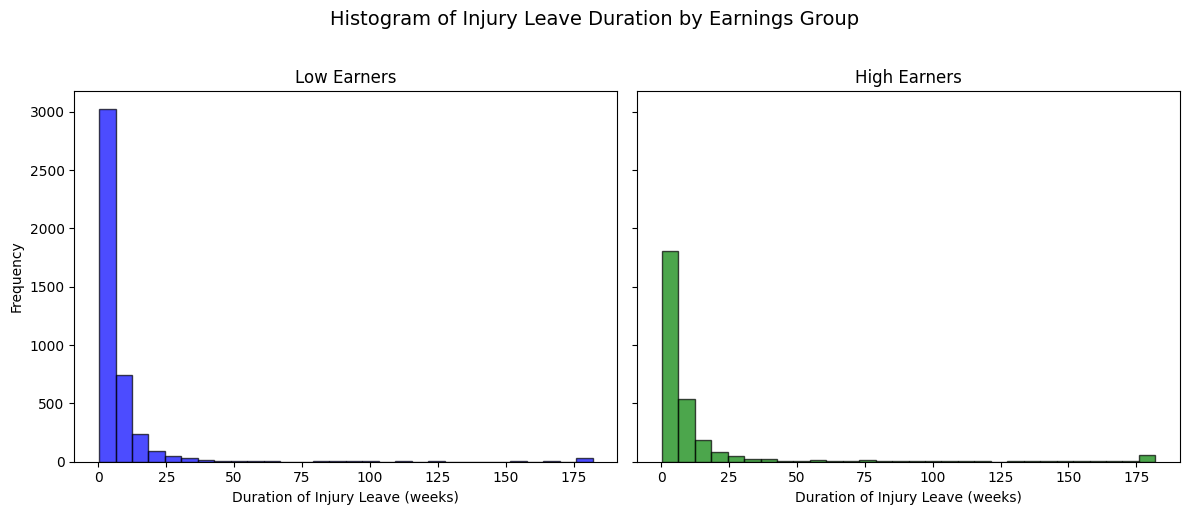

General statistics for Low Earners:
count    4298.000000
mean        8.004944
std        19.586868
min         0.250000
25%         2.000000
50%         4.000000
75%         8.000000
max       182.000000
Name: durat, dtype: float64

General statistics for High Earners:
count    2852.000000
mean       12.811536
std        30.211425
min         0.250000
25%         2.000000
50%         4.500000
75%         9.000000
max       182.000000
Name: durat, dtype: float64


In [6]:
durt_lowearn = data['durat'][data['highearn'] == 0]
durt_highearn = data['durat'][data['highearn'] == 1]

plot_histograms(
    data_list=[durt_lowearn, durt_highearn],
    titles=['Low Earners', 'High Earners'],
    xlabel='Duration of Injury Leave (weeks)', 
    ylabel='Frequency',
    overall_title='Histogram of Injury Leave Duration by Earnings Group'
)

print("General statistics for Low Earners:")
print(durt_lowearn.describe())
print("\nGeneral statistics for High Earners:")
print(durt_highearn.describe())

This untransformed duration variable could be misleading most notably by how it presents a severe right skewness as it highlights the significant presence of outliers. 

### PART C

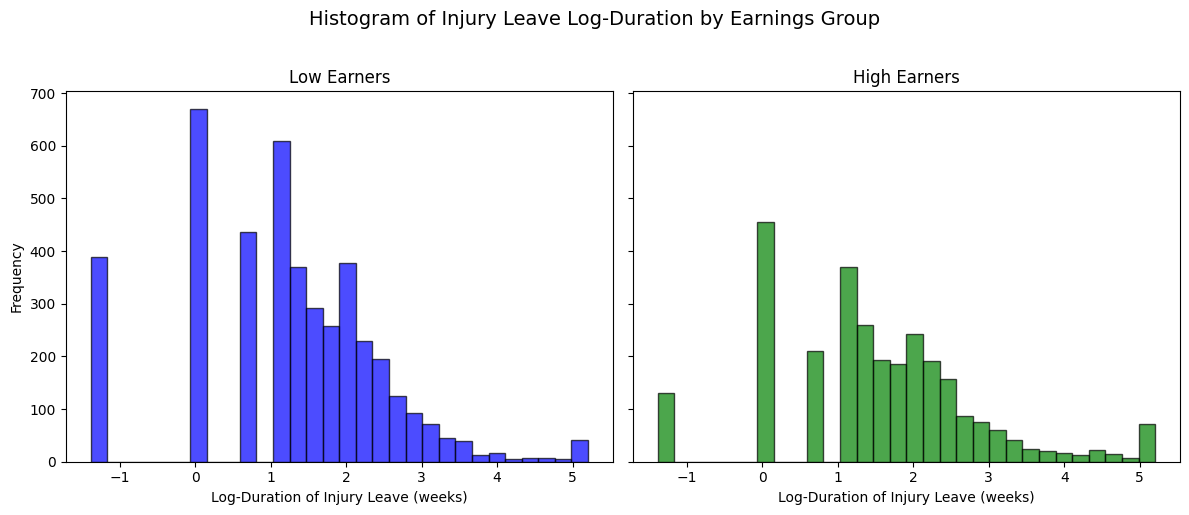

General statistics for Low Earners (log-duration):
count    4298.000000
mean        1.210356
std         1.281076
min        -1.386294
25%         0.693147
50%         1.386294
75%         2.079442
max         5.204007
Name: ldurat, dtype: float64

General statistics for High Earners (log-duration):
count    2852.000000
mean        1.517105
std         1.327970
min        -1.386294
25%         0.693147
50%         1.497866
75%         2.197225
max         5.204007
Name: ldurat, dtype: float64

Mean difference in log-duration between High and Low Earners: 0.3067
High earners have on average 35.90% longer injury leave durations than low earners.


In [7]:
ldurat_lowearn = data['ldurat'][data['highearn'] == 0]
ldurat_highearn = data['ldurat'][data['highearn'] == 1]

plot_histograms(
    data_list=[ldurat_lowearn, ldurat_highearn],
    titles=['Low Earners', 'High Earners'],
    xlabel='Log-Duration of Injury Leave (weeks)', 
    ylabel='Frequency',
    overall_title='Histogram of Injury Leave Log-Duration by Earnings Group'
)

print("General statistics for Low Earners (log-duration):")
print(ldurat_lowearn.describe())
print("\nGeneral statistics for High Earners (log-duration):")
print(ldurat_highearn.describe())

print(f"\nMean difference in log-duration between High and Low Earners: {ldurat_highearn.mean() - ldurat_lowearn.mean():.4f}")
print(f"High earners have on average {100*(np.exp(ldurat_highearn.mean() - ldurat_lowearn.mean())-1):.2f}% longer injury leave durations than low earners.")

While this data does tell us that higher earners have on average 35.9% longer injury leaver durations relative to lower earners, this isn't enough to make causal claims about their correlations as there are still unconsidered factors such as <b>reverse causality</b> and <b>endogeneity</b> that affect the robustness of the claims.

### PART D

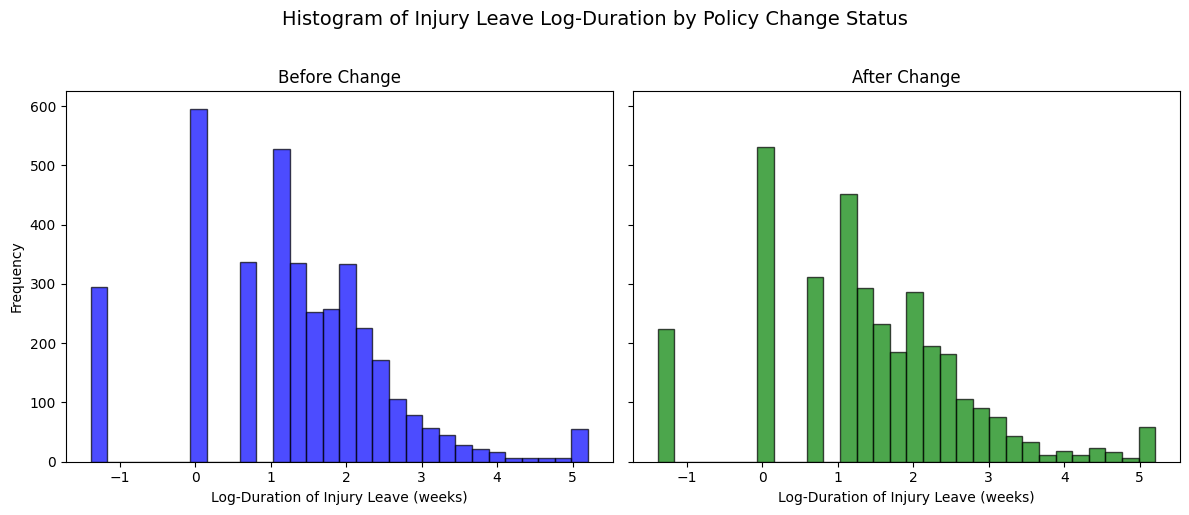

General statistics for Before Change:
count    3766.000000
mean        1.283448
std         1.289479
min        -1.386294
25%         0.693147
50%         1.386294
75%         2.079442
max         5.204007
Name: ldurat, dtype: float64

General statistics for After Change:
count    3384.000000
mean        1.387537
std         1.327479
min        -1.386294
25%         0.693147
50%         1.386294
75%         2.197225
max         5.204007
Name: ldurat, dtype: float64

Mean difference in log-duration between After Change and Before Change: 0.1041
After the policy change, injury leave durations are on average 10.97% longer than before the change.


In [8]:
ldurt_bfchnge = data['ldurat'][data['afchnge'] == 0]
ldurt_afchnge = data['ldurat'][data['afchnge'] == 1]

plot_histograms(
    data_list=[ldurt_bfchnge, ldurt_afchnge],
    titles=['Before Change', 'After Change'],
    xlabel='Log-Duration of Injury Leave (weeks)', 
    ylabel='Frequency',
    overall_title='Histogram of Injury Leave Log-Duration by Policy Change Status'
)

print("General statistics for Before Change:")
print(ldurt_bfchnge.describe())
print("\nGeneral statistics for After Change:")
print(ldurt_afchnge.describe())

print(f"\nMean difference in log-duration between After Change and Before Change: {ldurt_afchnge.mean() - ldurt_bfchnge.mean():.4f}")
print(f"After the policy change, injury leave durations are on average {100*(np.exp(ldurt_afchnge.mean() - ldurt_bfchnge.mean())-1):.2f}% longer than before the change.")

Similar to the conclusions made in part c, however, the correlation found does not mean that there is a causal relationship between Log Duration injury leaves and changes in policy. This is because there are several factors such as high vs lower earners or external economic conditions which could have an endogenous effect on the regressors.

### PART E

The DID model is:

    ldurat = β₀ + β₁(highearn) + β₂(afchnge) + β₃(highearn × afchnge) + ε

Where:
- β₀ = Baseline (low earners, before 1980)
- β₁ = Pre-existing difference (high vs low, before policy)
- β₂ = Time trend (change for control group)
- β₃ = DID estimator (causal effect of policy)

In [14]:
# DID interaction term
data['interaction'] = data['highearn'] * data['afchnge']

# Group means for each subgroup
low_before = data['ldurat'][(data['highearn'] == 0) & (data['afchnge'] == 0)].mean()
low_after = data['ldurat'][(data['highearn'] == 0) & (data['afchnge'] == 1)].mean()
high_before = data['ldurat'][(data['highearn'] == 1) & (data['afchnge'] == 0)].mean()
high_after = data['ldurat'][(data['highearn'] == 1) & (data['afchnge'] == 1)].mean()

#DID calculated manually
time_effect_control = low_after - low_before
time_effect_treated = high_after - high_before
did_manual = time_effect_treated - time_effect_control

print(f"\n### Manual DID Calculation:")
print(f"  Time effect for Control group:  {time_effect_control:.4f}")
print(f"  Time effect for Treated group:  {time_effect_treated:.4f}")
print(f"  Difference-in-Differences:      {did_manual:.4f}")
print(f"\n  Interpretation: {(np.exp(did_manual) - 1) * 100:.2f}% increase in duration")


### Manual DID Calculation:
  Time effect for Control group:  0.0236
  Time effect for Treated group:  0.2120
  Difference-in-Differences:      0.1883

  Interpretation: 20.73% increase in duration


In [15]:
# Model without controls
model1 = ols('ldurat ~ highearn + afchnge + interaction', data=data).fit()

# Print regression results
print(model1.summary())

# Extract and display key results
beta_0 = model1.params['Intercept']
beta_1 = model1.params['highearn']
beta_2 = model1.params['afchnge']
beta_3 = model1.params['interaction']

print("\n### Coefficient Interpretations:")
print(f"  β₀ (Intercept):  {beta_0:.4f} - Baseline for low earners before 1980")
print(f"  β₁ (highearn):   {beta_1:.4f} - Pre-policy difference (high vs low)")
print(f"  β₂ (afchnge):    {beta_2:.4f} - Time trend for control group")
print(f"  β₃ (interaction): {beta_3:.4f} *** DID ESTIMATE ***")

# Calculate percentage effect
pct_effect1 = (np.exp(beta_3) - 1) * 100
print(f"\n*** CAUSAL EFFECT: {pct_effect1:.2f}% increase in duration ***")
print(f"    Standard Error: {model1.bse['interaction']:.4f}")
print(f"    T-statistic: {model1.tvalues['interaction']:.3f}")
print(f"    P-value: {model1.pvalues['interaction']:.4f}")
print(f"    95% CI: [{model1.conf_int().loc['interaction', 0]:.4f}, "
      f"{model1.conf_int().loc['interaction', 1]:.4f}]")

# Verify manual calculation matches regression
print(f"\n### Verification:")
print(f"  Manual DID calculation:     {did_manual:.4f}")
print(f"  Regression β₃ coefficient:  {beta_3:.4f}")
print(f"  Match: {np.isclose(did_manual, beta_3)}")

                            OLS Regression Results                            
Dep. Variable:                 ldurat   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     38.34
Date:                Thu, 23 Oct 2025   Prob (F-statistic):           1.42e-24
Time:                        19:13:42   Log-Likelihood:                -12011.
No. Observations:                7150   AIC:                         2.403e+04
Df Residuals:                    7146   BIC:                         2.406e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       1.1993      0.027     44.241      

### Part F

In [17]:
# Model with controls
controls = ['male', 'married', 'age', 'hosp', 'indust', 'injtype', 'lprewage', 'totmed']
print(f"\nControl variables included: {controls}")

# Build formula
formula2 = 'ldurat ~ highearn + afchnge + interaction + ' + ' + '.join(controls)
print(f"\nRegression formula:\n{formula2}")

# Estimate Model 2
model2 = ols(formula2, data=data).fit()

# Print regression results
print("\n" + model2.summary().as_text())

# Extract key results
beta_3_controls = model2.params['interaction']
pct_effect2 = (np.exp(beta_3_controls) - 1) * 100

print("\n### Model 2 Results:")
print(f"  β₃ (interaction): {beta_3_controls:.4f} *** DID ESTIMATE WITH CONTROLS ***")
print(f"\n*** CAUSAL EFFECT: {pct_effect2:.2f}% increase in duration ***")
print(f"    Standard Error: {model2.bse['interaction']:.4f}")
print(f"    T-statistic: {model2.tvalues['interaction']:.3f}")
print(f"    P-value: {model2.pvalues['interaction']:.4f}")
print(f"    95% CI: [{model2.conf_int().loc['interaction', 0]:.4f}, "
      f"{model2.conf_int().loc['interaction', 1]:.4f}]")


Control variables included: ['male', 'married', 'age', 'hosp', 'indust', 'injtype', 'lprewage', 'totmed']

Regression formula:
ldurat ~ highearn + afchnge + interaction + male + married + age + hosp + indust + injtype + lprewage + totmed

                            OLS Regression Results                            
Dep. Variable:                 ldurat   R-squared:                       0.173
Model:                            OLS   Adj. R-squared:                  0.172
Method:                 Least Squares   F-statistic:                     129.8
Date:                Thu, 23 Oct 2025   Prob (F-statistic):          2.35e-271
Time:                        19:14:27   Log-Likelihood:                -10832.
No. Observations:                6822   AIC:                         2.169e+04
Df Residuals:                    6810   BIC:                         2.177e+04
Df Model:                          11                                         
Covariance Type:            nonrobust            

In [18]:
print("MODEL COMPARISON")
print("=" * 80)

comparison = pd.DataFrame({
    'Model': ['Model 1: No Controls', 'Model 2: With Controls'],
    'DID Coefficient (β₃)': [beta_3, beta_3_controls],
    'Std Error': [model1.bse['interaction'], model2.bse['interaction']],
    'T-statistic': [model1.tvalues['interaction'], model2.tvalues['interaction']],
    'P-value': [model1.pvalues['interaction'], model2.pvalues['interaction']],
    'Effect Size (%)': [pct_effect1, pct_effect2],
    'R-squared': [model1.rsquared, model2.rsquared],
    'Adj R-squared': [model1.rsquared_adj, model2.rsquared_adj],
    'N': [int(model1.nobs), int(model2.nobs)]
})

print("\n", comparison.to_string(index=False))

# Statistical significance indicators
print("\n### Significance:")
for i, (model_name, pval) in enumerate(zip(['Model 1', 'Model 2'], 
                                            [model1.pvalues['interaction'], 
                                             model2.pvalues['interaction']])):
    if pval < 0.01:
        sig = "*** (p < 0.01)"
    elif pval < 0.05:
        sig = "** (p < 0.05)"
    elif pval < 0.10:
        sig = "* (p < 0.10)"
    else:
        sig = "(not significant)"
    print(f"  {model_name}: {sig}")

MODEL COMPARISON

                  Model  DID Coefficient (β₃)  Std Error  T-statistic  P-value  Effect Size (%)  R-squared  Adj R-squared    N
  Model 1: No Controls              0.188350   0.062794     2.999489 0.002714        20.725572   0.015842       0.015429 7150
Model 2: With Controls              0.166631   0.058875     2.830262 0.004665        18.131830   0.173274       0.171938 6822

### Significance:
  Model 1: *** (p < 0.01)
  Model 2: *** (p < 0.01)
